# Voyager 2 at Saturn

Plots and animation of the Voyager 2 slingshot encounter with Saturn in August 1981

Uses `astroquery` to get orbital state vector data from the JPL Horizons database for Saturn and Voyager 2.

In [23]:
%matplotlib inline

import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

# astropy bits we need

from astropy.time import Time

# JPL Horizons query 

from astroquery.jplhorizons import Horizons

# suppress nuisance warnings

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [24]:
# Aspect ratio
#
# Exceptions:
#    spectra use full width we use 5:2=2.5 aspect ratio
#
# graphic aspect ratio = width/height

aspect = 1.0 #16.0/9.0

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 1.0

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 7
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## Convenience functions

 * `plotCircle()` plot an open circle
 * `fillCircle()` plot a filled circle


In [25]:
def plotCircle(ax,xc,yc,r,color,ltype='-',alpha=1,lw=0.5):
    theta = np.linspace(0,2*np.pi,360,endpoint=True)
    xs = xc + r*np.cos(theta)
    ys = yc + r*np.sin(theta)
    ax.plot(xs,ys,linestyle=ltype,color=color,alpha=alpha,lw=lw)
    
def fillCircle(ax,xc,yc,r,color,alpha=1):
    theta = np.linspace(0,2*np.pi,360,endpoint=True)
    xs = xc + r*np.cos(theta)
    ys = yc + r*np.sin(theta)
    ax.fill(xs,ys,color=color,alpha=alpha)

## Voyager 2 Saturn encounter data

Voyager 2 epochs for 2 days around close encounter on 1981 Aug 25 us used to trace the motions of Voyager 2 and Saturn

Extract state vectors from the JPL Horizons database using `astroquery`

In [26]:
# Saturn orbit track 3 months around Voyager 2 encounter to trace its orbit arc

obj = Horizons(id="Saturn Barycenter",epochs={"start":"1981-08-01","stop":"1981-10-01","step":"1h"})

satOrb = obj.vectors()
satOrbx = np.array(satOrb["x"])
satOrby = np.array(satOrb["y"])
satOrbz = np.array(satOrb["z"])

# Voyager 2 trajector for 2 days around Saturn encounter on a 10-minute time step

obj = Horizons(id="Voyager 2",epochs={"start":"1981-08-25","stop":"1981-08-27","step":"10m"})
vgr2 = obj.vectors()
vgr2x = np.array(vgr2["x"])
vgr2y = np.array(vgr2["y"])
vgr2z = np.array(vgr2["z"])
vgr2vx = np.array(vgr2["vx"])
vgr2vy = np.array(vgr2["vy"])
vgr2vz = np.array(vgr2["vz"])

# Saturn during the encounter, same epochs as Voyager 2 above

obj = Horizons(id="Saturn Barycenter",epochs={"start":"1981-08-25","stop":"1981-08-27","step":"10m"})

sat = obj.vectors()
satx = np.array(sat["x"])
saty = np.array(sat["y"])
satz = np.array(sat["z"])
satvx = np.array(sat["vx"])
satvy = np.array(sat["vy"])
satvz = np.array(sat["vz"])

# heliocentric position and velocity vectors for Voytager 2 and Saturn

vgr2R = []
vgr2V = []
satR = []
satV = []
for i in range(len(satx)):
    vgr2R.append([vgr2x[i],vgr2y[i],vgr2z[i]])
    vgr2V.append([vgr2vx[i],vgr2vy[i],vgr2vz[i]])
    satR.append([satx[i],saty[i],satz[i]])
    satV.append([satvx[i],satvy[i],satvz[i]])

# closest approach

dx = satx-vgr2x
dy = saty-vgr2y
dz = satz-vgr2z

dSat = np.sqrt(dx*dx + dy*dy + dz*dz)
iClosest = np.argmin(dSat)

satxMin = satx[iClosest]
satyMin = saty[iClosest]

# Voyager 2 orbit in Saturn reference frame

vgrSatX = vgr2x - satx
vgrSatY = vgr2y - saty
vgrSatZ = vgr2z - satz

### Trajectories of Saturn and Voyager 2 in the heliocentric reference frame

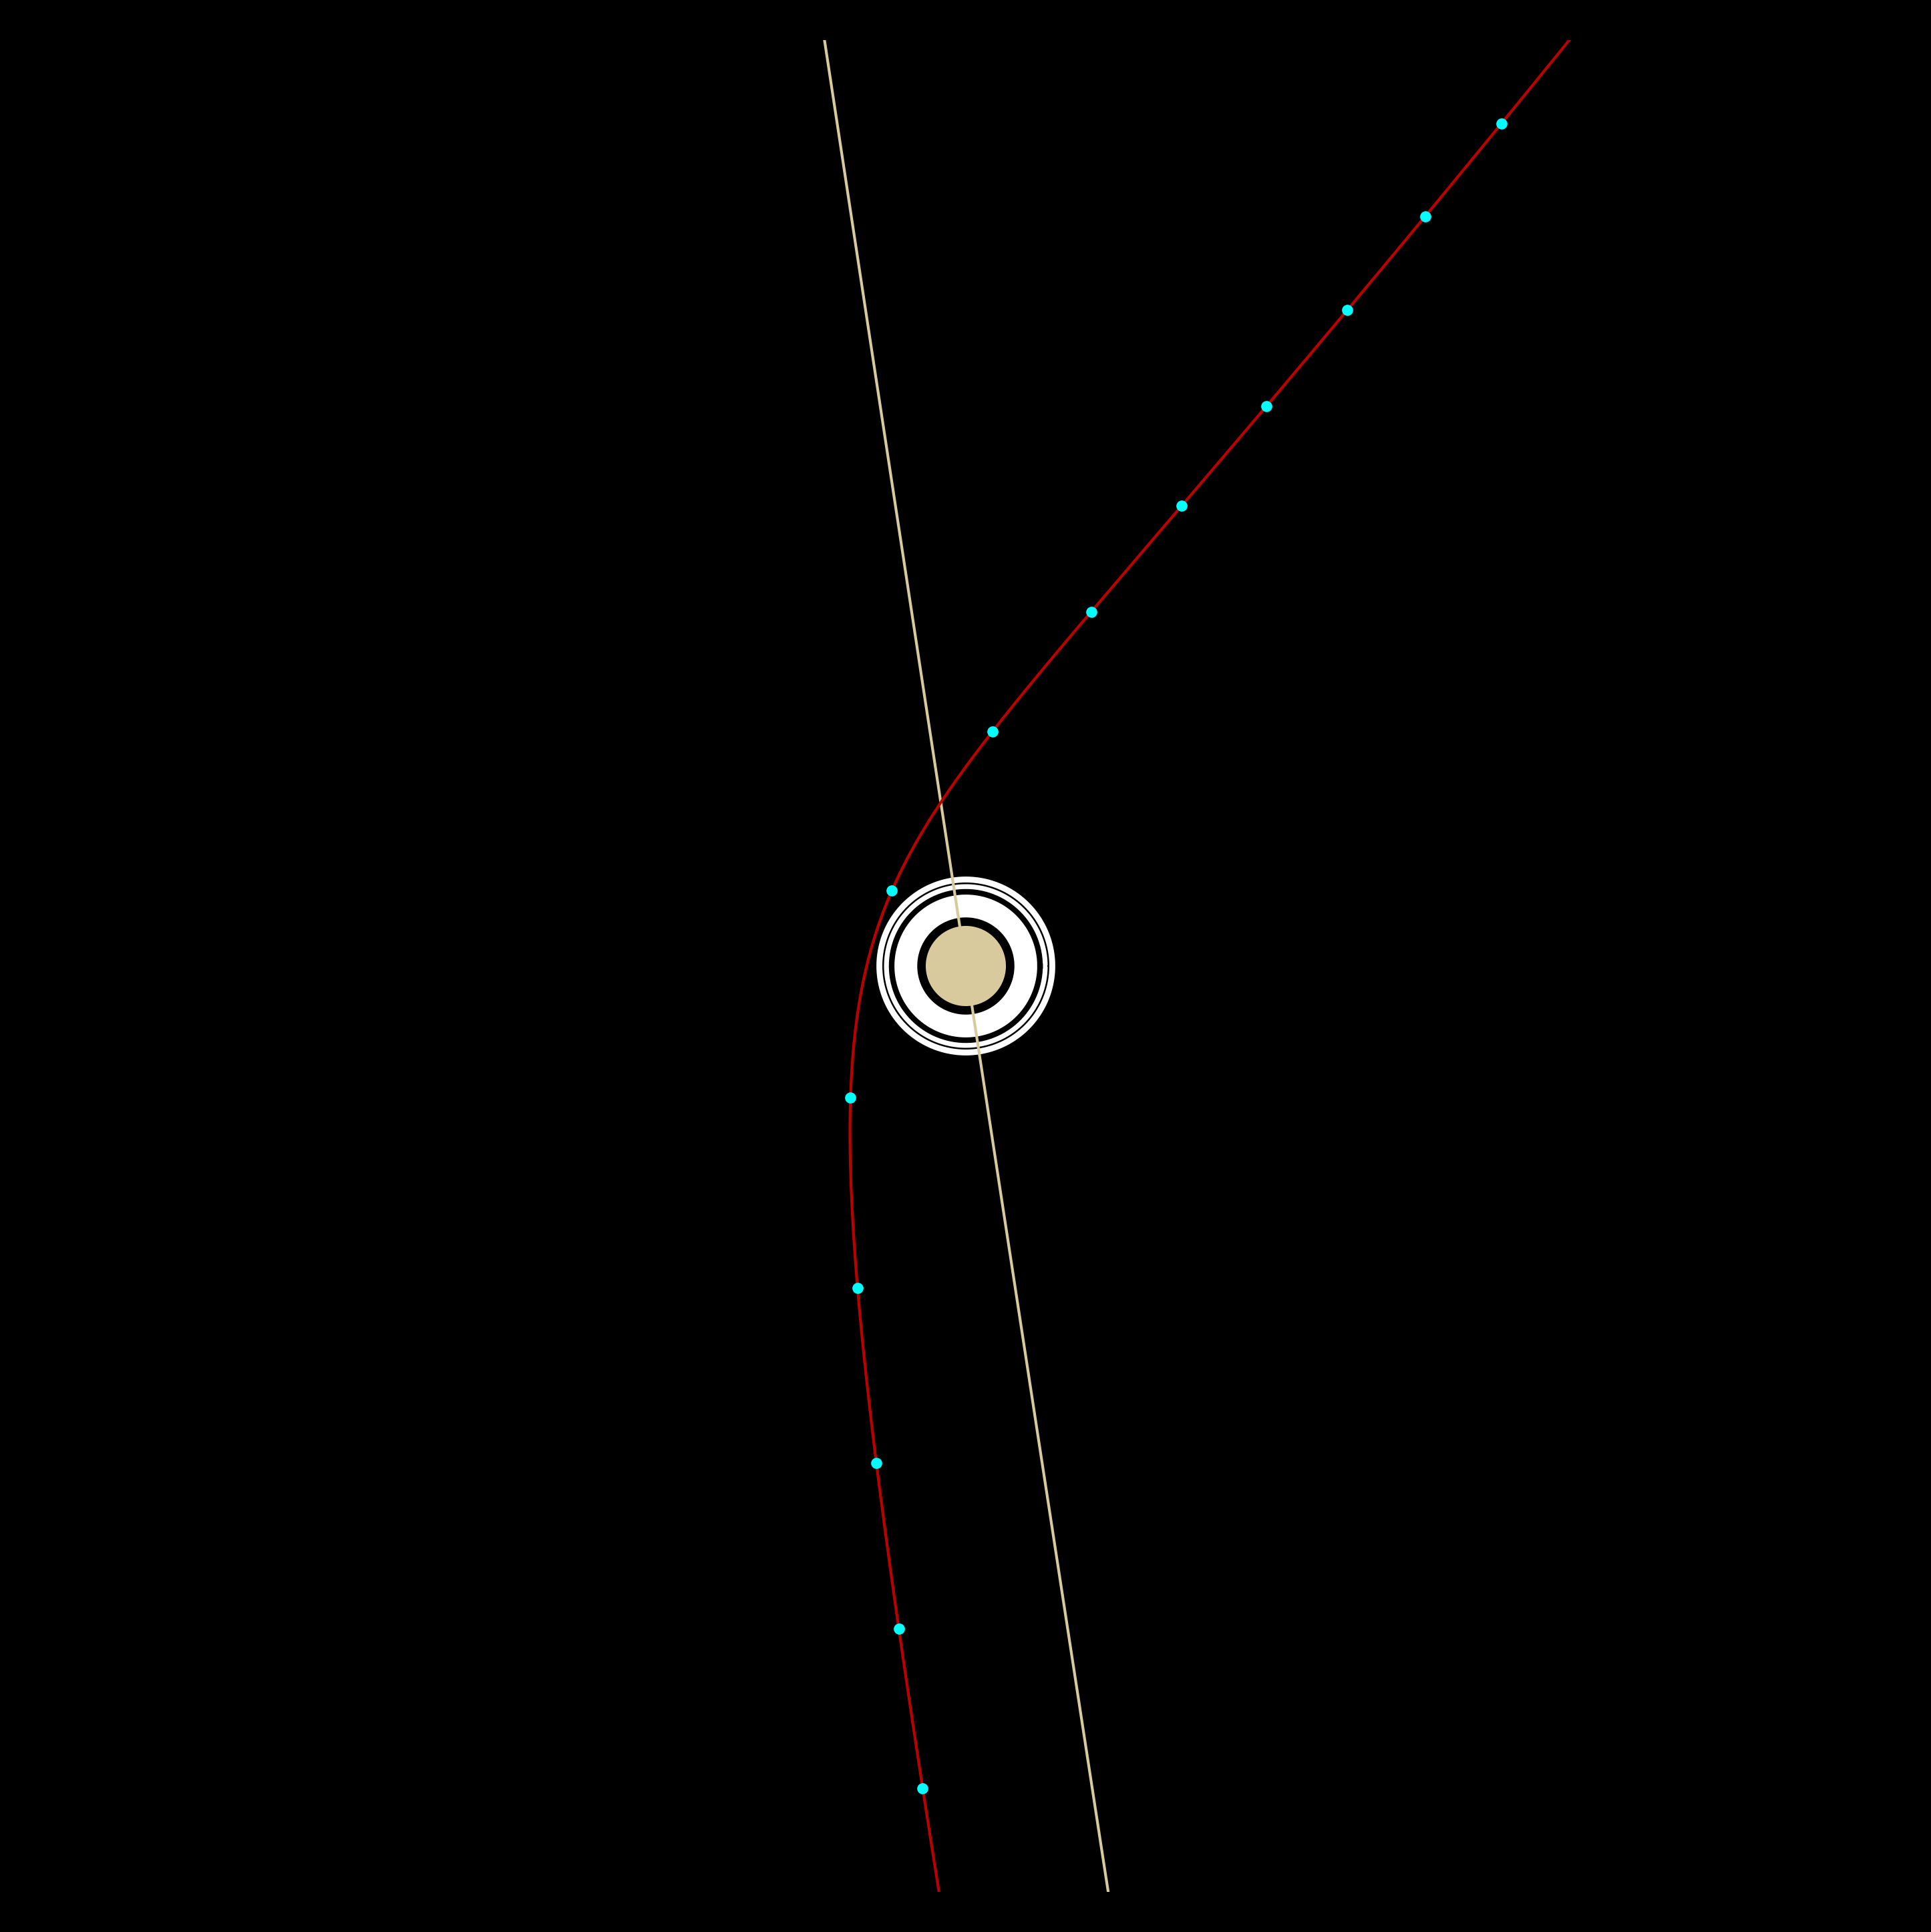

In [31]:
plotFile = f"Voyager2_Saturn_helio.png"

dau = 0.01
axMin = satxMin-dau
axMax = satxMin+dau
ayMin = satyMin-dau
ayMax = satyMin+dau

plt.style.use('dark_background')

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)
    
ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

ax.set_xlim(axMin,axMax)
ax.set_xticks([])
ax.set_ylim(ayMin,ayMax)
ax.set_yticks([])
ax.set_axis_off()

ax.set_aspect(True)

ax.plot(satOrbx,satOrby,'-',lw=0.5,color="#d8ca9d",zorder=9)

# Voyager 2, dots every 3h (18 points for 10min timestep)

ax.plot(vgr2x,vgr2y,'-',lw=0.5,color="#bb0000",zorder=9)
ax.plot(vgr2x[::18],vgr2y[::18],'o',ms=2,mfc="cyan",mec=None,mew=0,zorder=9)

#ax.plot(satV2x,satV2y,'o',mfc="orange",ms=3,mec=None,mew=0,alpha=1,zorder=9)
#ax.plot(satV2x[0],satV2y[0],'o',mfc="red",ms=2,mec=None,mew=0,alpha=1,zorder=10)

# and the sun

ax.plot(0,0,'o',ms=1.5,mfc='yellow',mec='yellow',mew=0.3,alpha=1,zorder=10)

# saturn from above

R_sat = 60268/1.496e8
R_inner = 74000/1.496e8
R_outer = 140000/1.496e8
R_encke = 133570/1.496e8
R_cassini = 0.5*(117580+122170)/1.496e8

fillCircle(ax,satxMin,satyMin,R_outer,"white")
fillCircle(ax,satxMin,satyMin,R_inner,"black")
fillCircle(ax,satxMin,satyMin,R_sat,"#d8ca9d")
plotCircle(ax,satxMin,satyMin,R_encke,"black",lw=0.3)
plotCircle(ax,satxMin,satyMin,R_cassini,"black",lw=1)

# save hardcopy

#plt.savefig(plotFile,bbox_inches='tight',facecolor='black')

plt.show()

### Voyager 2 trajectory in the Saturn reference frame


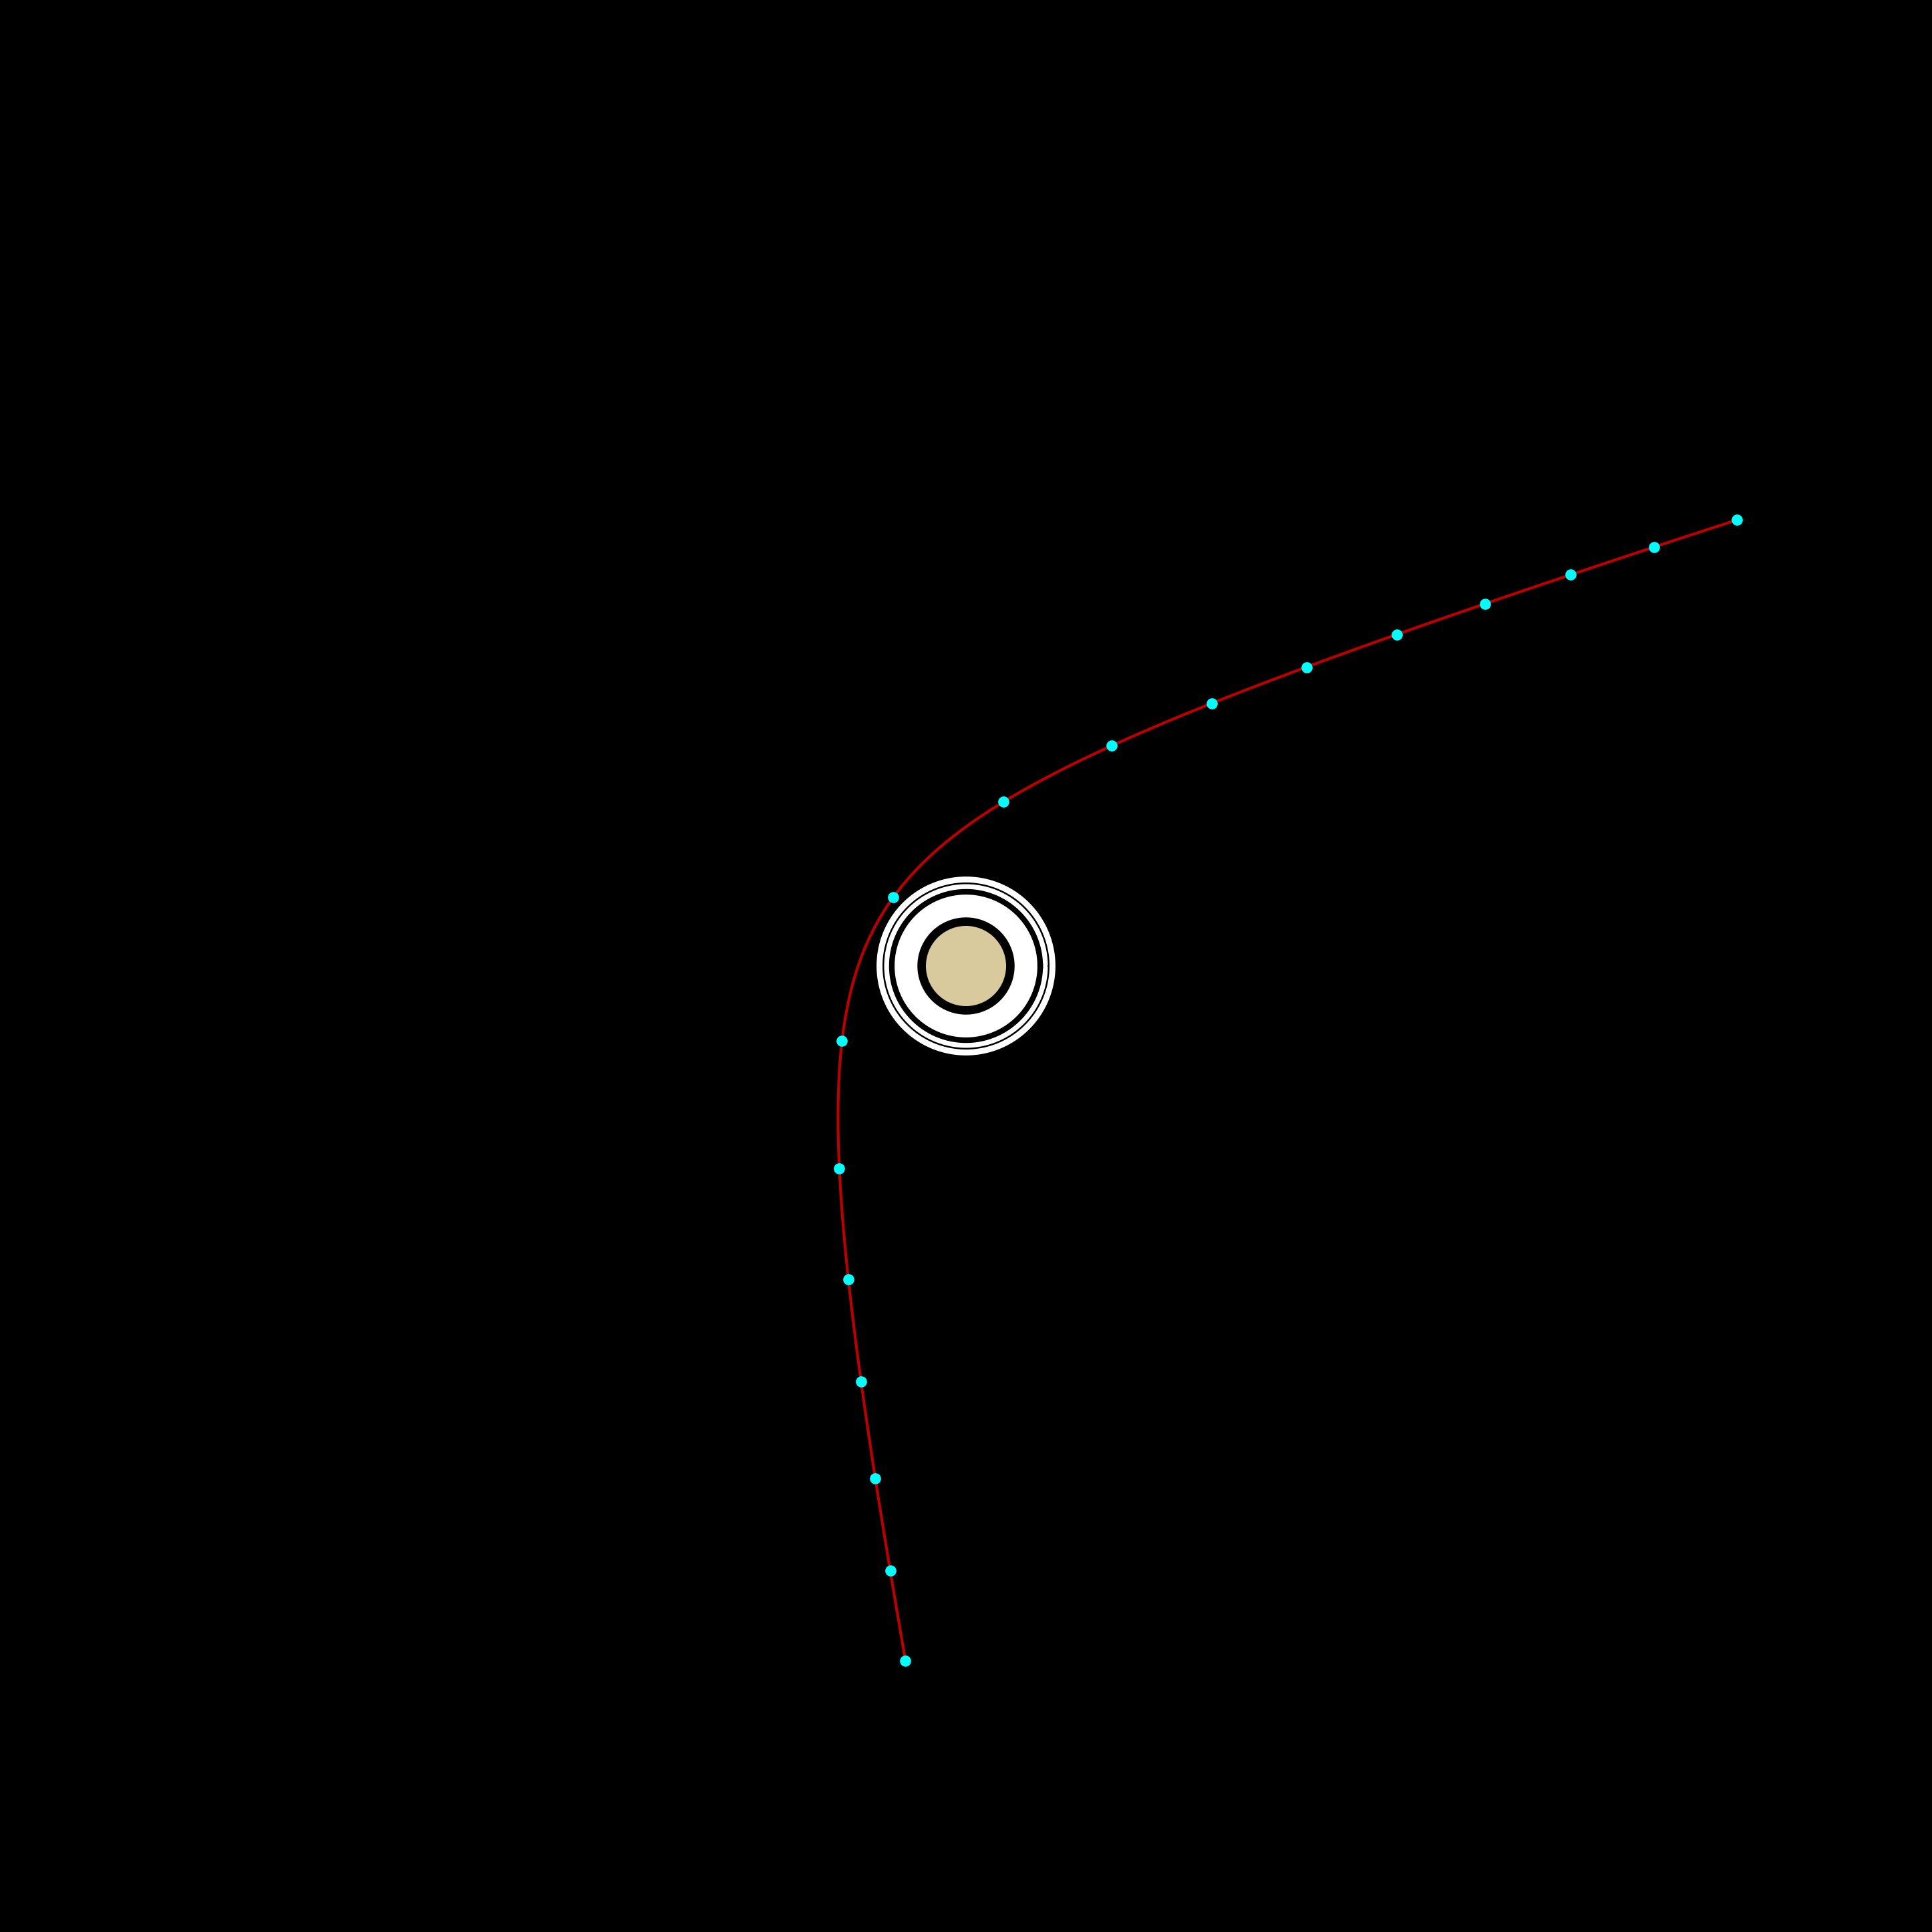

In [32]:
plotFile = f"Voyager2_Saturn.png"

dau = 0.01
axMin = -dau
axMax = dau
ayMin = -dau
ayMax = dau

plt.style.use('dark_background')

fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)
    
ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

ax.set_xlim(axMin,axMax)
ax.set_xticks([])
ax.set_ylim(ayMin,ayMax)
ax.set_yticks([])
ax.set_axis_off()

ax.set_aspect(True)

# Voyager trajectory in the Saturn moving frame

ax.plot(vgrSatX,vgrSatY,'-',lw=0.5,color="#bb0000",zorder=9)

# milestones (3h interval - every 18th point for 10m step)

ax.plot(vgrSatX[::18],vgrSatY[::18],'o',ms=2,mfc="cyan",mec=None,mew=0,zorder=9)

# saturn from above

R_sat = 60268/1.496e8
R_inner = 74000/1.496e8
R_outer = 140000/1.496e8
R_encke = 133570/1.496e8
R_cassini = 0.5*(117580+122170)/1.496e8

fillCircle(ax,0,0,R_outer,"white")
fillCircle(ax,0,0,R_inner,"black")
fillCircle(ax,0,0,R_sat,"#d8ca9d")
plotCircle(ax,0,0,R_encke,"black",lw=0.3)
plotCircle(ax,0,0,R_cassini,"black",lw=1)

# save hardcopy

plt.savefig(plotFile,bbox_inches='tight',facecolor='black')

plt.show()

## Encounter heliocentric speed and angular momentum

In [29]:
au2km = 1.496978707e8 # km/au
d2sec = 86400 # sec/day
for i in range(len(vgr2R)):
    v = au2km*np.array(vgr2V[i])/d2sec
    r = au2km*np.array(vgr2R[i])
    vs = au2km*np.array(satV[i])/d2sec
    L = np.cross(r,v)
    Lm = np.sqrt(np.inner(L,L))
    Km = np.inner(v,v)
    v_vgr = np.sqrt(Km)
    v_sat = np.sqrt(np.inner(vs,vs))
    dV = v_vgr - v_sat
    print(f"{v_vgr:.3f} km/s, L/m={Lm:.3f} km^2/s, KE/m={Km:.3f} km^2/s^2, v_Sat={v_sat:.3f} km/s deltaV={dV:.3f} km/s")
    

17.308 km/s, L/m=15824271538.561 km^2/s, KE/m=299.558 km^2/s^2, v_Sat=9.607 km/s deltaV=7.701 km/s
17.318 km/s, L/m=15829290248.685 km^2/s, KE/m=299.913 km^2/s^2, v_Sat=9.607 km/s deltaV=7.711 km/s
17.328 km/s, L/m=15834379572.326 km^2/s, KE/m=300.273 km^2/s^2, v_Sat=9.607 km/s deltaV=7.722 km/s
17.339 km/s, L/m=15839540946.731 km^2/s, KE/m=300.637 km^2/s^2, v_Sat=9.607 km/s deltaV=7.732 km/s
17.350 km/s, L/m=15844775847.352 km^2/s, KE/m=301.005 km^2/s^2, v_Sat=9.607 km/s deltaV=7.743 km/s
17.360 km/s, L/m=15850085789.095 km^2/s, KE/m=301.378 km^2/s^2, v_Sat=9.607 km/s deltaV=7.754 km/s
17.371 km/s, L/m=15855472327.629 km^2/s, KE/m=301.755 km^2/s^2, v_Sat=9.607 km/s deltaV=7.764 km/s
17.382 km/s, L/m=15860937060.737 km^2/s, KE/m=302.137 km^2/s^2, v_Sat=9.607 km/s deltaV=7.775 km/s
17.393 km/s, L/m=15866481629.731 km^2/s, KE/m=302.524 km^2/s^2, v_Sat=9.607 km/s deltaV=7.787 km/s
17.404 km/s, L/m=15872107720.915 km^2/s, KE/m=302.915 km^2/s^2, v_Sat=9.607 km/s deltaV=7.798 km/s
17.416 km/